In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
import gc
import time
import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


In [3]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
cpus = tf.config.experimental.list_physical_devices(device_type='CPU')
print(gpus, cpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
print(tf.__version__)

1.14.0


### 载入数据

In [97]:
data_train=pd.read_csv('F:/TensorFlow/xinjiang/traindata20240724.csv',header=0,encoding='utf_8')
data_train.info()
data_train.className.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Columns: 319 entries, className to Y
dtypes: float64(17), int64(301), object(1)
memory usage: 3.3+ MB


array(['芦苇草甸', '芦苇盐生草甸（含盐生半灌木）', '盐生草荒漠', '木本猪毛菜荒漠',
       '寸草苔草甸（1:100图，薹草、杂类草草甸）', '蒿叶猪毛菜荒漠', '新疆银穗草草原', '戈壁藜荒漠', '麻黄荒漠',
       '合头草荒漠', '短叶假木贼荒漠', '枇杷柴荒漠', '芦苇盐生草甸', '霸王荒漠', '含盐生半灌木的芦苇盐生草甸',
       '膜果麻黄荒漠', '疏叶骆驼刺盐生草甸', '柽柳灌丛', '多枝柽柳荒漠', '含多枝柽柳的芦苇盐生草甸', '花花柴盐生草甸',
       '含多枝柽柳的花花柴盐生草甸', '裸地', '驼绒藜荒漠', '冷蒿荒漠草原', '猪毛菜属荒漠', '芨芨草草原',
       '旱蒿荒漠', '短花针茅荒漠草原', '镰芒针茅矮半灌木荒漠草原', '梭梭荒漠', '沙拐枣属荒漠', '芨芨草草甸',
       '柽柳属荒漠', '紫花针茅草原', '新疆银穗草、穗状寒生羊茅荒漠草原', '小针茅荒漠草原', '紫花针茅、新疆银穗草草原',
       '蒿属荒漠', '锦鸡儿、镰芒针茅荒漠草原', '针茅草原', '盐生假木贼荒漠', '线叶嵩草草甸', '绢蒿属荒漠',
       '沙生针茅荒漠草原', '羊茅、杂类草草甸草原', '昆仑针茅、高山绢蒿荒漠草原', '早熟禾杂类草草甸', '克氏针茅草原',
       '其它薹草草甸', '羊茅草原', '其它嵩草草甸', '高山嵩草高寒草甸', '杂类草高寒草甸', '早熟禾草甸',
       '草原苔草、杂类草草甸草原', '白茎绢蒿荒漠', '人工草地', '短花针茅典型草原', '高山绢蒿荒漠', '鸭茅草甸',
       '早熟禾、羽衣草草甸', '镰芒针茅荒漠草原', '小蓬荒漠', '薹草、珠芽蓼高寒草甸', '新疆薹草草原', '新疆针茅草原',
       '盐生木荒漠', '粗毛锦鸡儿荒漠', '红砂荒漠', '胡杨荒漠', '芦苇草原', '芦苇荒漠', '锦鸡儿荒漠',
       '骆驼刺荒漠'], dtype=object)

In [98]:
pd.set_option('display.max_rows', None)
print(data_train['className'].value_counts())

芦苇草甸                      106
裸地                        100
梭梭荒漠                       61
针茅草原                       44
多枝柽柳荒漠                     44
紫花针茅草原                     44
驼绒藜荒漠                      41
含多枝柽柳的芦苇盐生草甸               38
疏叶骆驼刺盐生草甸                  33
枇杷柴荒漠                      29
芦苇盐生草甸                     27
旱蒿荒漠                       26
盐生假木贼荒漠                    26
芨芨草草原                      24
柽柳属荒漠                      24
线叶嵩草草甸                     22
其它薹草草甸                     21
芦苇荒漠                       21
猪毛菜属荒漠                     20
麻黄荒漠                       20
膜果麻黄荒漠                     19
高山绢蒿荒漠                     19
白茎绢蒿荒漠                     18
戈壁藜荒漠                      18
红砂荒漠                       17
其它嵩草草甸                     17
胡杨荒漠                       17
冷蒿荒漠草原                     17
粗毛锦鸡儿荒漠                    17
沙拐枣属荒漠                     16
合头草荒漠                      16
小蓬荒漠                       14
花花柴盐生草甸                    14
短叶假木贼荒漠   

In [99]:
data_train.head()

,className,num,AET2020,AET2021,AET2101,AET2102,AET2103,AET2104,AET2105,AET2106,AET2107,AET2108,AET2109,AET2110,AET2111,AET2112,aspect,dem,slop,EVI220101,EVI220117,EVI220202,EVI220218,EVI220306,EVI220322,EVI220407,EVI220423,EVI220509,EVI220525,EVI220610,EVI220626,EVI220712,EVI220728,EVI220813,EVI220829,EVI220914,EVI220930,EVI221016,EVI221101,EVI221117,EVI221203,EVI221219,FPAR220101,FPAR220117,FPAR220202,FPAR220218,FPAR220306,FPAR220322,FPAR220407,FPAR220423,FPAR220509,FPAR220525,FPAR220610,FPAR220626,FPAR220712,FPAR220728,FPAR220813,FPAR220829,FPAR220914,FPAR220930,FPAR221024,FPAR221109,FPAR221125,FPAR221211,FPAR221227,LAI220101,LAI220117,LAI220202,LAI220218,LAI220306,LAI220322,LAI220407,LAI220423,LAI220509,LAI220525,LAI220610,LAI220626,LAI220712,LAI220728,LAI220813,LAI220829,LAI220914,LAI220930,LAI221024,LAI221109,LAI221125,LAI221211,LAI221227,LST2018,LST2019,LST2020,LST2021,LST2022,LST220101,LST220117,LST220202,LST220218,LST220306,LST220322,LST220407,LST220423,LST220509,LST220525,LST220610,LST220626,LST220712,LST220728,LST220813,LST220829,LST220914,LST220930,LST221016,LST221101,LST221117,LST221203,LST221219,NDVI220101,NDVI220117,NDVI220202,NDVI220218,NDVI220306,NDVI220322,NDVI220407,NDVI220423,NDVI220509,NDVI220525,NDVI220610,NDVI220626,NDVI220712,NDVI220728,NDVI220813,NDVI220829,NDVI220914,NDVI220930,NDVI221016,NDVI221101,NDVI221117,NDVI221203,NDVI221219,PR2001,PR2002,PR2003,PR2004,PR2005,PR2006,PR2007,PR2008,PR2009,PR2010,PR2011,PR2012,PR2018,PR2019,PR2020,PR2021,PR2101,PR2102,PR2103,PR2104,PR2105,PR2106,PR2107,PR2108,PR2109,PR2110,PR2111,PR2112,SOIL2020,SOIL2021,SOIL2101,SOIL2102,SOIL2103,SOIL2104,SOIL2105,SOIL2106,SOIL2107,SOIL2108,SOIL2109,SOIL2110,SOIL2111,SOIL2112,GPP230101,GPP230117,GPP230202,GPP230218,GPP230306,GPP230322,GPP230407,GPP230423,GPP230509,GPP230525,GPP230610,GPP230626,GPP230712,GPP230728,GPP230813,GPP230829,GPP230914,GPP230930,GPP231016,GPP231101,GPP231117,GPP231203,GPP231219,SR230101b01,SR230101b02,SR230101b03,SR230101b04,SR230101b05,SR230101b06,SR230101b07,SR230109b01,SR230109b02,SR230109b03,SR230109b04,SR230109b05,SR230109b06,SR230109b07,SR230117b01,SR230117b02,SR230117b03,SR230117b04,SR230117b05,SR230117b06,SR230117b07,SR230125b01,SR230125b02,SR230125b03,SR230125b04,SR230125b05,SR230125b06,SR230125b07,SR230202b01,SR230202b02,SR230202b03,SR230202b04,SR230202b05,SR230202b06,SR230202b07,SR230210b01,SR230210b02,SR230210b03,SR230210b04,SR230210b05,SR230210b06,SR230210b07,SR230218b01,SR230218b02,SR230218b03,SR230218b04,SR230218b05,SR230218b06,SR230218b07,SR230226b01,SR230226b02,SR230226b03,SR230226b04,SR230226b05,SR230226b06,SR230226b07,SR230306b01,SR230314b01,SR230322b01,SR230330b01,SR230407b01,SR230415b01,SR230423b01,SR230704b07,SR230712b01,SR230712b02,SR230712b03,SR230712b04,SR230712b05,SR230712b06,SR230712b07,SR230720b01,SR230720b02,SR230720b03,SR230720b04,SR230720b05,SR230720b06,SR230720b07,SR230728b01,SR230728b02,SR230728b03,SR230728b04,SR230728b05,SR230728b06,SR230728b07,SR230805b01,SR230805b02,SR230805b03,SR230805b04,SR230805b05,SR230805b06,SR230805b07,SR230813b01,SR230813b02,SR230813b03,SR230813b04,SR230813b05,SR230813b06,SR230813b07,SR230821b01,SR230821b02,SR230821b03,SR230821b04,SR230821b05,SR230821b06,SR230821b07,SR230829b01,SR230829b02,SR230829b03,SR230829b04,SR230829b05,SR230829b06,SR230829b07,X,Y
0,芦苇草甸,0,39.333333,47.000000,0,32,71,50,66,58,38,117,104,19,9,0,167.276001,1048,0.588682,166,0,-25,-36,-553,0,-804,0,0,0,0,-59,0,0,0,-246,-412,0,0,0,-233,-417,-511,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14600.68803,14594.91786,14600.87452,14540.29630,14379.50149,13101,13222,13249,13405,13658,13858,14286,14443,14585,14824,14876,14932,14842,14902,14811,14737,14648,14479,0,14155,13928,13504,13322,184,25,-36,-44,-659,0,-1494,0,0,0,0,-975,0,28,0,0,0,0,0,0,-786,-904,-1149,3,0,1,3,2,5,13,19,3,0,0,0,0.412677,0.461288,4.083333,4.916667,3,0,8,5,7,6,4,12,11,2,1,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,5,17,27,32,35,36,34,59,34,48,82,27,67,27,83,68,33,21,14,8,0,2

In [100]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 类别数量

In [101]:
num_classes = data_train['num'].nunique()
print(num_classes)

75


### 切分数据集（已经提前切分的话不用此部分）

In [102]:
split_index = int(len(data_all)*0.8)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 268 entries, 822 to 608
Columns: 319 entries, className to Y
dtypes: float64(17), int64(301), object(1)
memory usage: 670.0+ KB


In [103]:
#train_x = data_train.iloc[:,data_train.columns.str.contains("SR")]
#train_x = data_train.iloc[:,~ data_train.columns.str.contains('ClassName|num|SR')]
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

#test_x = data_test.iloc[:,data_train.columns.str.contains("SR")]
#test_x = data_test.iloc[:,~ data_test.columns.str.contains('ClassName|num|SR')]
test_x = data_test.iloc[:,2:]
test_y = data_test.loc[:, ['num']] 
train_x.head(), train_y.head()

(         AET2020    AET2021  AET2101  AET2102  AET2103  AET2104  AET2105  \
 1053   68.000000  46.000000        0       28       16       22      128   
 228    41.166667  36.250000        0       23       35       29      116   
 1048  148.833333  93.416667        0       59       45      123      153   
 1247   20.583333  20.583333        0       69        9       24       57   
 590    15.833333  16.666667        0       41       13       17       28   
 
       AET2106  AET2107  AET2108  AET2109  AET2110  AET2111  AET2112  \
 1053      142       96       53       57        6        4        0   
 228        72       38       58       51       17       10        0   
 1048      237      130      176      116       68       14        0   
 1247       56       23        3        4        2        0        0   
 590        67        2       28        4        0        0        0   
 
           aspect   dem       slop  EVI220101  EVI220117  EVI220202  EVI220218  \
 1053  359.992000   

### 不测试时使用全部数据训练

In [25]:
train_x = data_train.iloc[:,2:]
train_y = data_train.loc[:, ['num']] 

In [26]:
train_x.head()

,AET2020,AET2021,AET2101,AET2102,AET2103,AET2104,AET2105,AET2106,AET2107,AET2108,AET2109,AET2110,AET2111,AET2112,aspect,dem,slop,EVI220101,EVI220117,EVI220202,EVI220218,EVI220306,EVI220322,EVI220407,EVI220423,EVI220509,EVI220525,EVI220610,EVI220626,EVI220712,EVI220728,EVI220813,EVI220829,EVI220914,EVI220930,EVI221016,EVI221101,EVI221117,EVI221203,EVI221219,FPAR220101,FPAR220117,FPAR220202,FPAR220218,FPAR220306,FPAR220322,FPAR220407,FPAR220423,FPAR220509,FPAR220525,FPAR220610,FPAR220626,FPAR220712,FPAR220728,FPAR220813,FPAR220829,FPAR220914,FPAR220930,FPAR221024,FPAR221109,FPAR221125,FPAR221211,FPAR221227,LAI220101,LAI220117,LAI220202,LAI220218,LAI220306,LAI220322,LAI220407,LAI220423,LAI220509,LAI220525,LAI220610,LAI220626,LAI220712,LAI220728,LAI220813,LAI220829,LAI220914,LAI220930,LAI221024,LAI221109,LAI221125,LAI221211,LAI221227,LST2018,LST2019,LST2020,LST2021,LST2022,LST220101,LST220117,LST220202,LST220218,LST220306,LST220322,LST220407,LST220423,LST220509,LST220525,LST220610,LST220626,LST220712,LST220728,LST220813,LST220829,LST220914,LST220930,LST221016,LST221101,LST221117,LST221203,LST221219,NDVI220101,NDVI220117,NDVI220202,NDVI220218,NDVI220306,NDVI220322,NDVI220407,NDVI220423,NDVI220509,NDVI220525,NDVI220610,NDVI220626,NDVI220712,NDVI220728,NDVI220813,NDVI220829,NDVI220914,NDVI220930,NDVI221016,NDVI221101,NDVI221117,NDVI221203,NDVI221219,PR2001,PR2002,PR2003,PR2004,PR2005,PR2006,PR2007,PR2008,PR2009,PR2010,PR2011,PR2012,PR2018,PR2019,PR2020,PR2021,PR2101,PR2102,PR2103,PR2104,PR2105,PR2106,PR2107,PR2108,PR2109,PR2110,PR2111,PR2112,SOIL2020,SOIL2021,SOIL2101,SOIL2102,SOIL2103,SOIL2104,SOIL2105,SOIL2106,SOIL2107,SOIL2108,SOIL2109,SOIL2110,SOIL2111,SOIL2112,GPP230101,GPP230117,GPP230202,GPP230218,GPP230306,GPP230322,GPP230407,GPP230423,GPP230509,GPP230525,GPP230610,GPP230626,GPP230712,GPP230728,GPP230813,GPP230829,GPP230914,GPP230930,GPP231016,GPP231101,GPP231117,GPP231203,GPP231219,SR230101b01,SR230101b02,SR230101b03,SR230101b04,SR230101b05,SR230101b06,SR230101b07,SR230109b01,SR230109b02,SR230109b03,SR230109b04,SR230109b05,SR230109b06,SR230109b07,SR230117b01,SR230117b02,SR230117b03,SR230117b04,SR230117b05,SR230117b06,SR230117b07,SR230125b01,SR230125b02,SR230125b03,SR230125b04,SR230125b05,SR230125b06,SR230125b07,SR230202b01,SR230202b02,SR230202b03,SR230202b04,SR230202b05,SR230202b06,SR230202b07,SR230210b01,SR230210b02,SR230210b03,SR230210b04,SR230210b05,SR230210b06,SR230210b07,SR230218b01,SR230218b02,SR230218b03,SR230218b04,SR230218b05,SR230218b06,SR230218b07,SR230226b01,SR230226b02,SR230226b03,SR230226b04,SR230226b05,SR230226b06,SR230226b07,SR230306b01,SR230314b01,SR230322b01,SR230330b01,SR230407b01,SR230415b01,SR230423b01,SR230704b07,SR230712b01,SR230712b02,SR230712b03,SR230712b04,SR230712b05,SR230712b06,SR230712b07,SR230720b01,SR230720b02,SR230720b03,SR230720b04,SR230720b05,SR230720b06,SR230720b07,SR230728b01,SR230728b02,SR230728b03,SR230728b04,SR230728b05,SR230728b06,SR230728b07,SR230805b01,SR230805b02,SR230805b03,SR230805b04,SR230805b05,SR230805b06,SR230805b07,SR230813b01,SR230813b02,SR230813b03,SR230813b04,SR230813b05,SR230813b06,SR230813b07,SR230821b01,SR230821b02,SR230821b03,SR230821b04,SR230821b05,SR230821b06,SR230821b07,SR230829b01,SR230829b02,SR230829b03,SR230829b04,SR230829b05,SR230829b06,SR230829b07,X,Y
0,39.333333,47.000000,0,32,71,50,66,58,38,117,104,19,9,0,167.276001,1048,0.588682,166,0,-25,-36,-553,0,-804,0,0,0,0,-59,0,0,0,-246,-412,0,0,0,-233,-417,-511,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14600.68803,14594.91786,14600.87452,14540.29630,14379.50149,13101,13222,13249,13405,13658,13858,14286,14443,14585,14824,14876,14932,14842,14902,14811,14737,14648,14479,0,14155,13928,13504,13322,184,25,-36,-44,-659,0,-1494,0,0,0,0,-975,0,28,0,0,0,0,0,0,-786,-904,-1149,3,0,1,3,2,5,13,19,3,0,0,0,0.412677,0.461288,4.083333,4.916667,3,0,8,5,7,6,4,12,11,2,1,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,5,17,27,32,35,36,34,59,34,48,82,27,67,27,83,68,33,21,14,8,0,2505,2930,1630,2150,32

### 顺序编码转独热编码

In [104]:
train_y = tf.keras.utils.to_categorical(train_y)

In [105]:
pd.set_option('display.max_columns', None)
train_y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [106]:
train_y.shape[1]

75

In [107]:
dim_num = train_x.shape[1]
print(dim_num)

317


### 定义损失函数为Focal Loss

In [108]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [159]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(4096,input_dim=dim_num))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(2048,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(1024,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu',kernel_regularizer=tf.contrib.layers.l2_regularizer(0.003)))
model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(64,activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.3))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.01, patience=20, mode='auto')
model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
model.summary()

Model: "sequential_25"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_160 (Dense)            (None, 4096)              1302528   
_________________________________________________________________
batch_normalization_136 (Bat (None, 4096)              16384     
_________________________________________________________________
dense_161 (Dense)            (None, 2048)              8390656   
_________________________________________________________________
batch_normalization_137 (Bat (None, 2048)              8192      
_________________________________________________________________
dense_162 (Dense)            (None, 1024)              2098176   
_________________________________________________________________
batch_normalization_138 (Bat (None, 1024)              4096      
_________________________________________________________________
dense_163 (Dense)            (None, 512)             

### 开始训练

In [160]:
e = 400
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=64,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Epoch 1/400
1068/1068 [==============================] - 2s 2ms/sample - loss: 4.7760 - acc: 0.0936
Epoch 2/400
1068/1068 [==============================] - 0s 185us/sample - loss: 1.1854 - acc: 0.1217
Epoch 3/400
1068/1068 [==============================] - 0s 247us/sample - loss: 0.3873 - acc: 0.1245
Epoch 4/400
1068/1068 [==============================] - 0s 181us/sample - loss: 0.1694 - acc: 0.1610
Epoch 5/400
1068/1068 [==============================] - 0s 182us/sample - loss: 0.0851 - acc: 0.1451
Epoch 6/400
1068/1068 [==============================] - 0s 183us/sample - loss: 0.0513 - acc: 0.1376
Epoch 7/400
1068/1068 [==============================] - 0s 181us/sample - loss: 0.0339 - acc: 0.1610
Epoch 8/400
1068/1068 [==============================] - 0s 181us/sample - loss: 0.0265 - acc: 0.1451
Epoch 9/400
1068/1068 [==============================] - 0s 179us/sample - loss: 0.0220 - acc: 0.1517
Epoch 10/400
1068/1068 [==============================] - 0s 178us/sample - loss: 0.

1068/1068 [==============================] - 0s 182us/sample - loss: 0.0087 - acc: 0.2903
Epoch 81/400
1068/1068 [==============================] - 0s 177us/sample - loss: 0.0086 - acc: 0.2959
Epoch 82/400
1068/1068 [==============================] - 0s 176us/sample - loss: 0.0085 - acc: 0.3221
Epoch 83/400
1068/1068 [==============================] - 0s 183us/sample - loss: 0.0081 - acc: 0.3305
Epoch 84/400
1068/1068 [==============================] - 0s 181us/sample - loss: 0.0084 - acc: 0.3052
Epoch 85/400
1068/1068 [==============================] - 0s 173us/sample - loss: 0.0085 - acc: 0.2987
Epoch 86/400
1068/1068 [==============================] - 0s 173us/sample - loss: 0.0083 - acc: 0.3127
Epoch 87/400
1068/1068 [==============================] - 0s 179us/sample - loss: 0.0081 - acc: 0.3230
Epoch 88/400
1068/1068 [==============================] - 0s 178us/sample - loss: 0.0082 - acc: 0.3315
Epoch 89/400
1068/1068 [==============================] - 0s 180us/sample - loss: 0.00

1068/1068 [==============================] - 0s 176us/sample - loss: 0.0057 - acc: 0.5431
Epoch 160/400
1068/1068 [==============================] - 0s 177us/sample - loss: 0.0058 - acc: 0.5300
Epoch 161/400
1068/1068 [==============================] - 0s 172us/sample - loss: 0.0056 - acc: 0.5412
Epoch 162/400
1068/1068 [==============================] - 0s 178us/sample - loss: 0.0056 - acc: 0.5599
Epoch 163/400
1068/1068 [==============================] - 0s 171us/sample - loss: 0.0055 - acc: 0.5599
Epoch 164/400
1068/1068 [==============================] - 0s 173us/sample - loss: 0.0055 - acc: 0.5618
Epoch 165/400
1068/1068 [==============================] - 0s 180us/sample - loss: 0.0054 - acc: 0.5637
Epoch 166/400
1068/1068 [==============================] - 0s 179us/sample - loss: 0.0054 - acc: 0.5646
Epoch 167/400
1068/1068 [==============================] - 0s 177us/sample - loss: 0.0052 - acc: 0.5927
Epoch 168/400
1068/1068 [==============================] - 0s 174us/sample - l

1068/1068 [==============================] - 0s 179us/sample - loss: 0.0032 - acc: 0.8511
Epoch 238/400
1068/1068 [==============================] - 0s 177us/sample - loss: 0.0032 - acc: 0.8558
Epoch 239/400
1068/1068 [==============================] - 0s 173us/sample - loss: 0.0034 - acc: 0.8258
Epoch 240/400
1068/1068 [==============================] - 0s 176us/sample - loss: 0.0033 - acc: 0.8474
Epoch 241/400
1068/1068 [==============================] - 0s 175us/sample - loss: 0.0035 - acc: 0.8230
Epoch 242/400
1068/1068 [==============================] - 0s 172us/sample - loss: 0.0034 - acc: 0.8268
Epoch 243/400
1068/1068 [==============================] - 0s 173us/sample - loss: 0.0033 - acc: 0.8399
Epoch 244/400
1068/1068 [==============================] - 0s 171us/sample - loss: 0.0033 - acc: 0.8483
Epoch 245/400
1068/1068 [==============================] - 0s 183us/sample - loss: 0.0033 - acc: 0.8427
Epoch 246/400
1068/1068 [==============================] - 0s 172us/sample - l

1068/1068 [==============================] - 0s 191us/sample - loss: 0.0022 - acc: 0.9466
Epoch 316/400
1068/1068 [==============================] - 0s 182us/sample - loss: 0.0022 - acc: 0.9494
Epoch 317/400
1068/1068 [==============================] - 0s 175us/sample - loss: 0.0021 - acc: 0.9569
Epoch 318/400
1068/1068 [==============================] - 0s 174us/sample - loss: 0.0021 - acc: 0.9560
Epoch 319/400
1068/1068 [==============================] - 0s 173us/sample - loss: 0.0020 - acc: 0.9672
Epoch 320/400
1068/1068 [==============================] - 0s 177us/sample - loss: 0.0020 - acc: 0.9494
Epoch 321/400
1068/1068 [==============================] - 0s 179us/sample - loss: 0.0021 - acc: 0.9700
Epoch 322/400
1068/1068 [==============================] - 0s 180us/sample - loss: 0.0021 - acc: 0.9579
Epoch 323/400
1068/1068 [==============================] - 0s 195us/sample - loss: 0.0020 - acc: 0.9616
Epoch 324/400
1068/1068 [==============================] - 0s 173us/sample - l

1068/1068 [==============================] - 0s 174us/sample - loss: 0.0018 - acc: 0.9803
Epoch 394/400
1068/1068 [==============================] - 0s 171us/sample - loss: 0.0017 - acc: 0.9813
Epoch 395/400
1068/1068 [==============================] - 0s 169us/sample - loss: 0.0018 - acc: 0.9822
Epoch 396/400
1068/1068 [==============================] - 0s 181us/sample - loss: 0.0017 - acc: 0.9888
Epoch 397/400
1068/1068 [==============================] - 0s 194us/sample - loss: 0.0018 - acc: 0.9785
Epoch 398/400
1068/1068 [==============================] - 0s 178us/sample - loss: 0.0017 - acc: 0.9850
Epoch 399/400
1068/1068 [==============================] - 0s 188us/sample - loss: 0.0017 - acc: 0.9888
Epoch 400/400
1068/1068 [==============================] - 0s 175us/sample - loss: 0.0018 - acc: 0.9822
用时：00:01:27


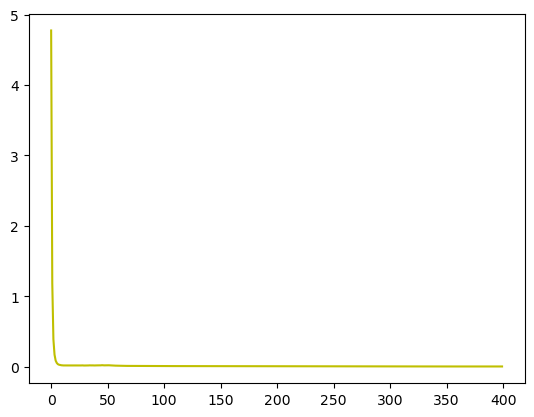

In [161]:
plt.plot(range(e),history.history.get('loss'),color =  'y')

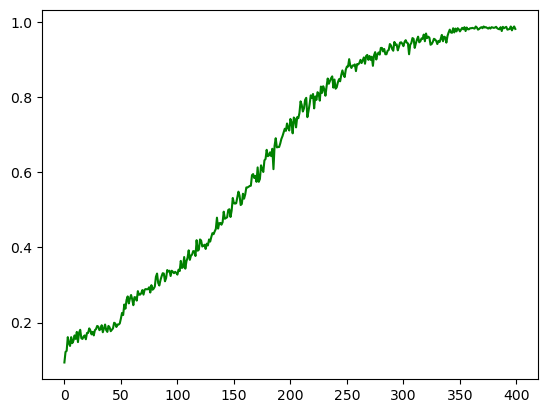

In [162]:
plt.plot(range(e),history.history.get('acc'),color =  'g')

### 计算准确率

In [163]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
acc_array = (test_y == test_r)
print('准确率：', np.sum(acc_array!=0)/len(acc_array))

268/268 [==============================] - 1s 2ms/sample
准确率： num    0.33209
dtype: float64


In [164]:
model.save(r'F:/TensorFlow/model_data/model_XJ_20240726.h5')

### 各类别准确率

In [21]:
test_y = list(chain.from_iterable(test_y))
test_r = list(chain.from_iterable(test_r))

def count_nums(true_labels, num_classes):
    initial_value = 0
    list_length = num_classes
    list_data = [ initial_value for i in range(list_length)]
    for i in range(0, num_classes):
        list_data[i] = true_labels.count(i)
    return list_data

def accuracy(confusion_matrix, true_labels, num_classes):
    # 各个类别的测试样本的个数
    list_data = count_nums(true_labels, num_classes)
 
    # 各个类别正确分类的个数
    initial_value = 0
    list_length = num_classes
    true_pred = [ initial_value for i in range(list_length)]
    for i in range(0,num_classes):
        true_pred[i] = confusion_matrix[i][i]
 
    # 计算各个样本被正确分类的正确率
    classveg = []
    acc = []
    for i in range(0, num_classes):
        classveg.append(0)
        acc.append(0)
 
    for i in range(0,num_classes):
        classveg[i] = i
        acc[i] = float(true_pred[i] / list_data[i])
    
    z = pd.DataFrame(list(zip(classveg,acc,list_data)), columns=['class_code', 'acc','count'])
    return z

op = tf.math.confusion_matrix(test_y, test_r)

acc = accuracy(op, test_y, num_classes)
print(acc)

NameError: name 'test_y' is not defined

### 出结果

In [36]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20240724_1.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/xinjiang/testdata20240716_1.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 5s 53us/sample
1
100000/100000 [==============================] - 5s 48us/sample
2
100000/100000 [==============================] - 5s 48us/sample
3
100000/100000 [==============================] - 5s 48us/sample
4
100000/100000 [==============================] - 5s 48us/sample
5
100000/100000 [==============================] - 5s 48us/sample
6
100000/100000 [==============================] - 5s 48us/sample
7
100000/100000 [==============================] - 5s 48us/sample
8
100000/100000 [==============================] - 5s 48us/sample
9
100000/100000 [==============================] - 5s 48us/sample
10
100000/100000 [==============================] - 5s 48us/sample
11
100000/100000 [==============================] - 5s 48us/sample
12
100000/100000 [==============================] - 5s 48us/sample
13
100000/100000 [==============================] - 5s 48us/sample
14
100000/100000 [==============================] - 5s 48us/sample
15
10

In [37]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20240724_2.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/xinjiang/testdata20240716_2.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 5s 49us/sample
1
100000/100000 [==============================] - 5s 50us/sample
2
100000/100000 [==============================] - 5s 50us/sample
3
100000/100000 [==============================] - 5s 49us/sample
4
100000/100000 [==============================] - 5s 49us/sample
5
100000/100000 [==============================] - 5s 50us/sample
6
100000/100000 [==============================] - 5s 50us/sample
7
100000/100000 [==============================] - 5s 51us/sample
8
100000/100000 [==============================] - 5s 50us/sample
9
100000/100000 [==============================] - 5s 50us/sample
10
100000/100000 [==============================] - 5s 49us/sample
11
100000/100000 [==============================] - 5s 50us/sample
12
100000/100000 [==============================] - 5s 50us/sample
13
100000/100000 [==============================] - 5s 50us/sample
14
100000/100000 [==============================] - 5s 51us/sample
15
10

In [38]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20240724_3.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/xinjiang/testdata20240716_3.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 5s 53us/sample
1
100000/100000 [==============================] - 5s 53us/sample
2
100000/100000 [==============================] - 5s 53us/sample
3
100000/100000 [==============================] - 5s 52us/sample
4
100000/100000 [==============================] - 5s 52us/sample
5
100000/100000 [==============================] - 5s 53us/sample
6
100000/100000 [==============================] - 5s 53us/sample
7
100000/100000 [==============================] - 5s 53us/sample
8
100000/100000 [==============================] - 5s 52us/sample
9
100000/100000 [==============================] - 5s 53us/sample
10
100000/100000 [==============================] - 5s 53us/sample
11
100000/100000 [==============================] - 5s 52us/sample
12
100000/100000 [==============================] - 5s 53us/sample
13
100000/100000 [==============================] - 5s 53us/sample
14
100000/100000 [==============================] - 5s 54us/sample
15
10

In [39]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20240724_4.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/xinjiang/testdata20240716_4.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 5s 49us/sample
1
100000/100000 [==============================] - 5s 49us/sample
2
100000/100000 [==============================] - 5s 49us/sample
3
100000/100000 [==============================] - 5s 49us/sample
4
100000/100000 [==============================] - 5s 49us/sample
5
100000/100000 [==============================] - 5s 49us/sample
6
100000/100000 [==============================] - 5s 48us/sample
7
100000/100000 [==============================] - 5s 49us/sample
8
100000/100000 [==============================] - 5s 50us/sample
9
100000/100000 [==============================] - 5s 49us/sample
10
100000/100000 [==============================] - 5s 49us/sample
11
100000/100000 [==============================] - 5s 50us/sample
12
100000/100000 [==============================] - 5s 50us/sample
13
100000/100000 [==============================] - 5s 50us/sample
14
100000/100000 [==============================] - 5s 51us/sample
15
10

In [40]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/xinjiang/testresult20240724_5.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/xinjiang/testdata20240716_5.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 5s 48us/sample
1
100000/100000 [==============================] - 5s 48us/sample
2
100000/100000 [==============================] - 5s 48us/sample
3
100000/100000 [==============================] - 5s 48us/sample
4
100000/100000 [==============================] - 5s 48us/sample
5
100000/100000 [==============================] - 5s 49us/sample
6
100000/100000 [==============================] - 5s 48us/sample
7
100000/100000 [==============================] - 5s 47us/sample
8
100000/100000 [==============================] - 5s 48us/sample
9
100000/100000 [==============================] - 5s 48us/sample
10
100000/100000 [==============================] - 5s 49us/sample
11
100000/100000 [==============================] - 5s 48us/sample
12
100000/100000 [==============================] - 5s 48us/sample
13
100000/100000 [==============================] - 5s 48us/sample
14
100000/100000 [==============================] - 5s 49us/sample
15
10